# Additional Root Cause Audit Notebook

Auditoría estructural del bloque `additional`, separando subbloques heterogéneos y evitando mezclar `financials`, `news`, `ipos`, `corporate_actions` y `economic` bajo una sola semántica.

In [1]:
%run C:/TSIS_Data/02_backtest_SmallCaps/notebooks/00_data_certification/auditoria/additional/cell_code/00_load_additional_audit_artifacts.py

**CACHE_ROOT**: `C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\00_data_certification\auditoria\additional\cache_v2`

In [2]:
from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

## 1. Snapshot Ejecutivo

In [3]:
display(pd.DataFrame([ADDITIONAL_BUILD_MANIFEST]))
display(additional_family_summary)
display(Markdown(f"**Artifacts en cache_v2:** `{len(list(CACHE_ROOT.glob('*.parquet')))} parquet(s)`"))

,built_at_utc,additional_root,universe_parquet,prior_audit_root,out_root,universe_tickers,artifacts
0,2026-05-01T18:02:53.201558+00:00,C:\TSIS_Data\data\additional,C:\TSIS_Data\v1\backtest_SmallCaps\runs\backte...,C:\TSIS_Data\v1\backtest_SmallCaps\runs\backte...,C:\TSIS_Data\v1\backtest_SmallCaps\notebooks\0...,4824,[additional_corp_actions_reference_overlap.par...


,dataset_family,datasets,ticker_based_datasets,macro_datasets,mean_effective_non_empty_pct,min_effective_non_empty_pct,rows_total_sum
0,corporate_actions_additional,"[dividends, splits, ticker_events]","[dividends, splits, ticker_events]",[],40.333000,26.078,61125
1,economic,"[inflation, inflation_expectations, treasury_y...",[],"[inflation, inflation_expectations, treasury_y...",NaN,NaN,17528
2,financials_core,"[balance_sheets, cash_flow_statements, income_...","[balance_sheets, cash_flow_statements, income_...",[],99.751333,99.710,621792
3,financials_ratios,[ratios],[ratios],[],46.269000,46.269,4824
4,ipos,[ipos],[ipos],[],26.016000,26.016,4850
5,news,[news],[news],[],80.203000,80.203,288093


**Artifacts en cache_v2:** `19 parquet(s)`

## 2. Cobertura Efectiva

,dataset,dataset_family,coverage_non_empty_pct,rows_total
0,balance_sheets,financials_core,99.772,136672
3,income_statements,financials_core,99.772,242897
1,cash_flow_statements,financials_core,99.710,242223
5,news,news,80.203,288093
8,ticker_events,corporate_actions_additional,56.032,5158
6,ratios,financials_ratios,46.269,4824
7,splits,corporate_actions_additional,38.889,6283
2,dividends,corporate_actions_additional,26.078,49684
4,ipos,ipos,26.016,4850


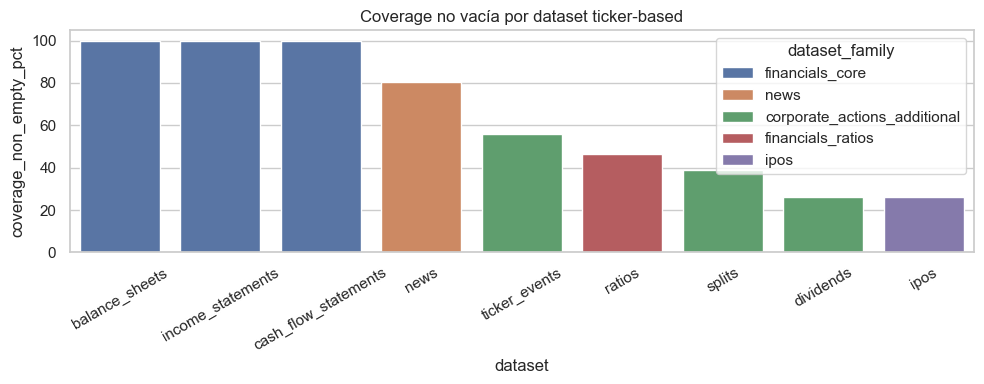

In [4]:
ticker_cov = additional_effective_coverage_summary[additional_effective_coverage_summary['dataset_kind'].eq('ticker_based')].copy()
display(ticker_cov[['dataset','dataset_family','coverage_non_empty_pct','rows_total']].sort_values('coverage_non_empty_pct', ascending=False))

fig, ax = plt.subplots(figsize=(10,4))
sns.barplot(data=ticker_cov.sort_values('coverage_non_empty_pct', ascending=False), x='dataset', y='coverage_non_empty_pct', hue='dataset_family', dodge=False, ax=ax)
ax.set_title('Coverage no vacía por dataset ticker-based')
ax.tick_params(axis='x', rotation=30)
ax.set_ylabel('coverage_non_empty_pct')
plt.tight_layout()
plt.show()

## 3. Schema y Shape Real

In [5]:
display(additional_schema_samples[['dataset','dataset_family','sample_rows','has_empty_flag','has_array_fields','has_nested_object_fields','columns']])

,dataset,dataset_family,sample_rows,has_empty_flag,has_array_fields,has_nested_object_fields,columns
0,balance_sheets,financials_core,11,False,True,False,"[tickers, cik, period_end, filing_date, fiscal..."
1,cash_flow_statements,financials_core,17,False,True,False,"[tickers, cik, period_end, filing_date, fiscal..."
2,dividends,corporate_actions_additional,40,False,False,False,"[cash_amount, currency, declaration_date, divi..."
3,income_statements,financials_core,20,False,True,False,"[tickers, cik, period_end, filing_date, fiscal..."
4,inflation,economic,950,False,False,False,"[date, cpi, cpi_year_over_year, cpi_core, pce,..."
5,inflation_expectations,economic,531,False,False,False,"[date, model_1_year, model_5_year, model_10_ye..."
6,ipos,ipos,1,False,False,False,"[ticker, last_updated, announced_date, listing..."
7,news,news,3,False,True,False,"[id, title, author, published_utc, article_url..."
8,ratios,financials_ratios,1,False,False,False,"[ticker, cik, date, price, average_volume, mar..."
9,splits,corporate_actions_additional,1,False,False,False,"[execution_date, id, split_from, split_to, tic..."


## 4. Financials

,dataset,dataset_family,non_empty_files,sample_rows,sample_columns,has_period_end,has_filing_date,has_timeframe,sample_timeframes,sample_has_multi_tickers_array
0,income_statements,financials_core,4813,20,"[tickers, cik, period_end, filing_date, fiscal...",True,True,True,"[annual, quarterly, trailing_twelve_months]",True
1,balance_sheets,financials_core,4813,11,"[tickers, cik, period_end, filing_date, fiscal...",True,True,True,"[annual, quarterly]",True
2,cash_flow_statements,financials_core,4810,17,"[tickers, cik, period_end, filing_date, fiscal...",True,True,True,"[annual, quarterly, trailing_twelve_months]",True
3,ratios,financials_ratios,2232,1,"[ticker, cik, date, price, average_volume, mar...",False,False,False,[],False


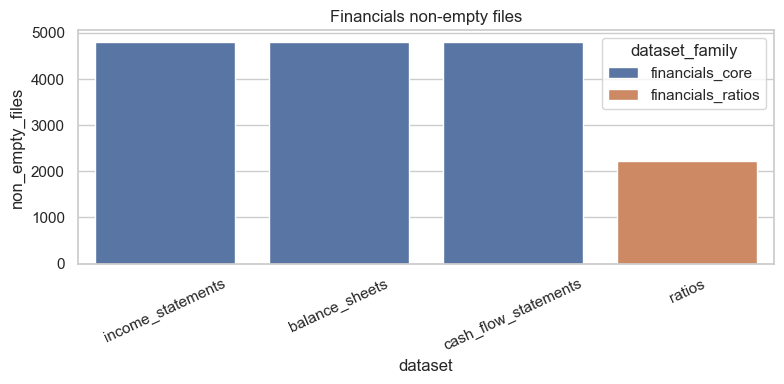

In [6]:
display(additional_financials_summary)
fig, ax = plt.subplots(figsize=(8,4))
sns.barplot(data=additional_financials_summary, x='dataset', y='non_empty_files', hue='dataset_family', dodge=False, ax=ax)
ax.set_title('Financials non-empty files')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## 5. News

In [7]:
display(additional_news_summary)
display(additional_news_ticker_density.head(25))
display(additional_news_multi_ticker_summary.head(25))

,dataset,non_empty_files,sample_rows,sample_columns,has_published_utc,has_multi_ticker_field,has_keywords,has_insights,sample_publishers
0,news,3869,3,"[id, title, author, published_utc, article_url...",True,True,True,True,"[Benzinga, MarketWatch]"


,ticker,news_rows
0,AMC,3600
1,TDOC,1628
2,TLRY,1563
3,AMN,1442
4,CGC,1241
5,BBBY,1167
6,NKLA,1115
7,SPCE,1097
8,SOL,1075
9,BYND,967


,file_path,ticker,rows,mean_tickers_per_news,max_tickers_per_news
0,C:\TSIS_Data\data\additional\news\news\ticker=...,AACT,3,4.000000,5
1,C:\TSIS_Data\data\additional\news\news\ticker=...,AAGR,9,17.000000,44
2,C:\TSIS_Data\data\additional\news\news\ticker=...,AAIC,112,64.098214,324
3,C:\TSIS_Data\data\additional\news\news\ticker=...,AAMC,39,18.717949,120
4,C:\TSIS_Data\data\additional\news\news\ticker=...,AAME,18,1.000000,1
5,C:\TSIS_Data\data\additional\news\news\ticker=...,AAN,241,7.078838,101
6,C:\TSIS_Data\data\additional\news\news\ticker=...,AARD,8,3.125000,10
7,C:\TSIS_Data\data\additional\news\news\ticker=...,AATC,13,1.000000,1
8,C:\TSIS_Data\data\additional\news\news\ticker=...,ABAT,17,11.823529,59
9,C:\TSIS_Data\data\additional\news\news\ticker=...,ABEO,129,7.697674,114


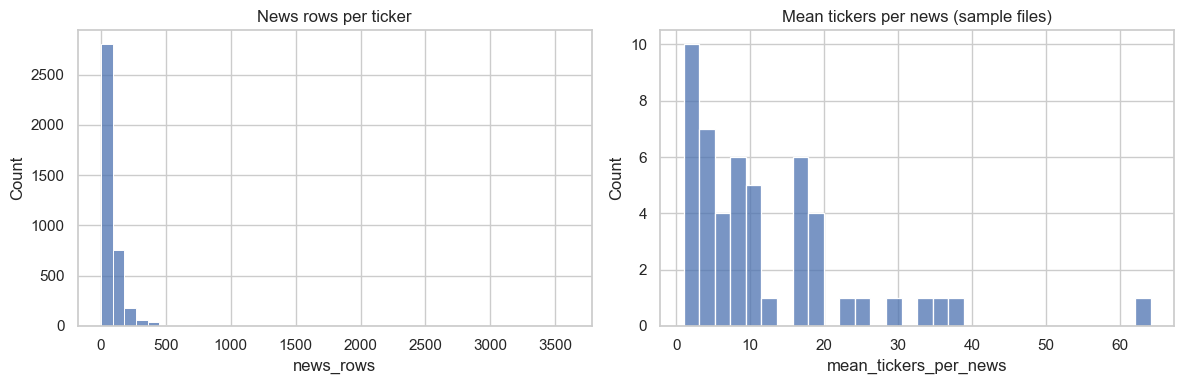

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(additional_news_ticker_density['news_rows'], bins=40, ax=axes[0])
axes[0].set_title('News rows per ticker')
sns.histplot(additional_news_multi_ticker_summary['mean_tickers_per_news'].dropna(), bins=30, ax=axes[1])
axes[1].set_title('Mean tickers per news (sample files)')
plt.tight_layout()
plt.show()

## 6. Corporate Actions e IPOs

In [9]:
display(additional_corporate_actions_summary)
display(additional_ipos_summary)

,dataset,dataset_family,non_empty_files,sample_rows,sample_columns
0,splits,corporate_actions_additional,1876,1,"[execution_date, id, split_from, split_to, tic..."
1,dividends,corporate_actions_additional,1258,40,"[cash_amount, currency, declaration_date, divi..."
2,ticker_events,corporate_actions_additional,2703,1,"[type, date, ticker, name, ticker_change.ticke..."


,dataset,dataset_family,non_empty_files,sample_rows,sample_columns
0,ipos,ipos,1255,1,"[ticker, last_updated, announced_date, listing..."


## 7. Economic

In [10]:
display(additional_macro_calendar_summary)

,dataset,file_present,rows_total,date_min,date_max,file_path,dataset_family
0,inflation,True,950,1947-01-01,2026-02-01,C:\TSIS_Data\data\additional\economic\inflatio...,economic
1,inflation_expectations,True,531,1982-01-01,2026-03-01,C:\TSIS_Data\data\additional\economic\inflatio...,economic
2,treasury_yields,True,16047,1962-01-02,2026-04-02,C:\TSIS_Data\data\additional\economic\treasury...,economic


## 8. Causal News

,news_link_bucket,events,tickers,mean_tickers_per_news
0,review_multi_ticker_ambiguous_news,169154,3627,16.264711
1,news_near_market_anomaly,98400,3103,1.000000
2,news_context_only,18296,2798,28.048590
3,news_near_halt_market_event,1268,707,1.000000
4,news_near_short_flow_only,20,15,6.200000


,ticker,news_date,title,n_tickers,is_multi_ticker,halt_visual_bucket,quotes_severity,trades_severity,short_market_link_bucket,news_link_bucket
0,AACT,2023-10-31,"Ares Acquisition Corp., X-energy scrap $1.8B m...",5,True,<NA>,PASS,PASS,NaN,news_context_only
1,AACT,2025-09-23,George Soros-Backed Kodiak Robotics Merger Fun...,3,True,<NA>,PASS,SOFT_FAIL,NaN,review_multi_ticker_ambiguous_news
2,AACT,2025-09-24,Kodiak Completes Business Combination with Are...,4,True,<NA>,SOFT_FAIL,SOFT_FAIL,NaN,review_multi_ticker_ambiguous_news
3,AAGR,2023-12-08,Why Comtech Telecommunications Shares Are Trad...,40,True,confirmed_halt_microstructure_coherent,SOFT_FAIL,SOFT_FAIL,NaN,review_multi_ticker_ambiguous_news
4,AAGR,2023-12-11,Why Green Giant Shares Are Trading Lower By Ar...,21,True,<NA>,SOFT_FAIL,SOFT_FAIL,NaN,review_multi_ticker_ambiguous_news
5,AAGR,2023-12-11,African Agriculture Reports Expanded Activitie...,1,False,<NA>,SOFT_FAIL,SOFT_FAIL,NaN,news_near_market_anomaly
6,AAGR,2023-12-11,Why bluebird bio Shares Are Trading Higher? He...,44,True,<NA>,SOFT_FAIL,SOFT_FAIL,NaN,review_multi_ticker_ambiguous_news
7,AAGR,2023-12-12,Why Johnson Controls International Shares Are ...,38,True,<NA>,SOFT_FAIL,HARD_FAIL,NaN,review_multi_ticker_ambiguous_news
8,AAGR,2023-12-18,African Agriculture Inc. Holdings Welcomes Mr....,1,False,<NA>,SOFT_FAIL,SOFT_FAIL,NaN,news_near_market_anomaly
9,AAGR,2024-01-10,Top 3 Risk Off Stocks That Are Set To Fly In Q1,3,True,<NA>,SOFT_FAIL,SOFT_FAIL,NaN,review_multi_ticker_ambiguous_news


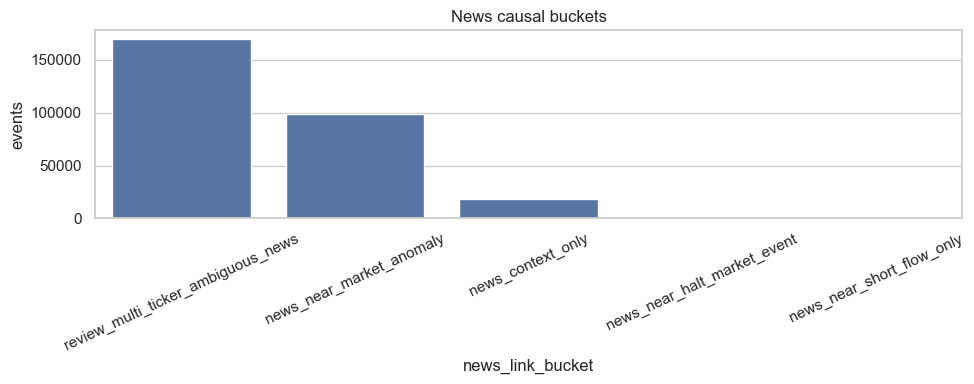

In [11]:
display(additional_news_link_summary)
display(additional_news_market_link_candidates[['ticker','news_date','title','n_tickers','is_multi_ticker','halt_visual_bucket','quotes_severity','trades_severity','short_market_link_bucket','news_link_bucket']].head(30))

fig, ax = plt.subplots(figsize=(10,4))
sns.barplot(data=additional_news_link_summary, x='news_link_bucket', y='events', ax=ax)
ax.set_title('News causal buckets')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## 9. IPOs y Solape con Reference

In [12]:
display(additional_ipo_link_summary)
display(additional_ipo_market_link_candidates[['ticker','listing_date','ipo_status','halt_visual_bucket','quotes_severity','trades_severity','ipo_link_bucket']].head(30))
display(additional_corp_actions_reference_overlap_summary)
display(additional_corp_actions_reference_overlap.head(30))

,ipo_link_bucket,events,tickers
0,ipo_near_market_anomaly,676,668
1,ipo_market_clean,449,443
2,ipo_near_halt_market_event,156,156


,ticker,listing_date,ipo_status,halt_visual_bucket,quotes_severity,trades_severity,ipo_link_bucket
0,AARD,2025-02-13,history,confirmed_halt_microstructure_coherent,SOFT_FAIL,SOFT_FAIL,ipo_near_halt_market_event
1,ABGI,2021-02-17,history,<NA>,SOFT_FAIL,SOFT_FAIL,ipo_near_market_anomaly
2,ABOS,2021-06-29,history,<NA>,NaN,NaN,ipo_market_clean
3,ABSI,2021-07-22,history,<NA>,SOFT_FAIL,SOFT_FAIL,ipo_near_market_anomaly
4,ABTX,2015-10-08,history,<NA>,SOFT_FAIL,PASS,ipo_near_market_anomaly
5,ACCD,2020-07-02,history,<NA>,SOFT_FAIL,SOFT_FAIL,ipo_near_market_anomaly
6,ACDC,2022-05-12,history,<NA>,NaN,NaN,ipo_market_clean
7,ACET,2018-01-26,history,<NA>,PASS,HARD_FAIL,ipo_near_market_anomaly
8,ACIU,2016-09-23,history,<NA>,SOFT_FAIL,PASS,ipo_near_market_anomaly
9,ACRE,2012-04-26,history,<NA>,HARD_FAIL,SOFT_FAIL,ipo_near_market_anomaly


,dataset,overlap_bucket,tickers,rows,overlap_rows
0,dividends,reference_exact_overlap,1253,1253,45968
1,dividends,reference_present_no_exact_overlap,5,5,0
2,splits,reference_exact_overlap,1858,1858,3293
3,splits,reference_present_no_exact_overlap,18,18,0
4,ticker_events,reference_present_no_exact_overlap,2703,2703,0


,dataset,ticker,additional_rows,reference_rows,overlap_rows,reference_file_exists,overlap_bucket
0,dividends,AAIC,40,1,0,True,reference_present_no_exact_overlap
1,dividends,AAME,16,1,0,True,reference_present_no_exact_overlap
2,dividends,AAN,15,1,0,True,reference_present_no_exact_overlap
3,dividends,AATC,20,20,20,True,reference_exact_overlap
4,dividends,ABIO,1,1,1,True,reference_exact_overlap
5,dividends,ABL,1,1,1,True,reference_exact_overlap
6,dividends,ABTX,11,11,11,True,reference_exact_overlap
7,dividends,ABVC,57,57,57,True,reference_exact_overlap
8,dividends,AC,20,20,20,True,reference_exact_overlap
9,dividends,ACB,3,3,3,True,reference_exact_overlap


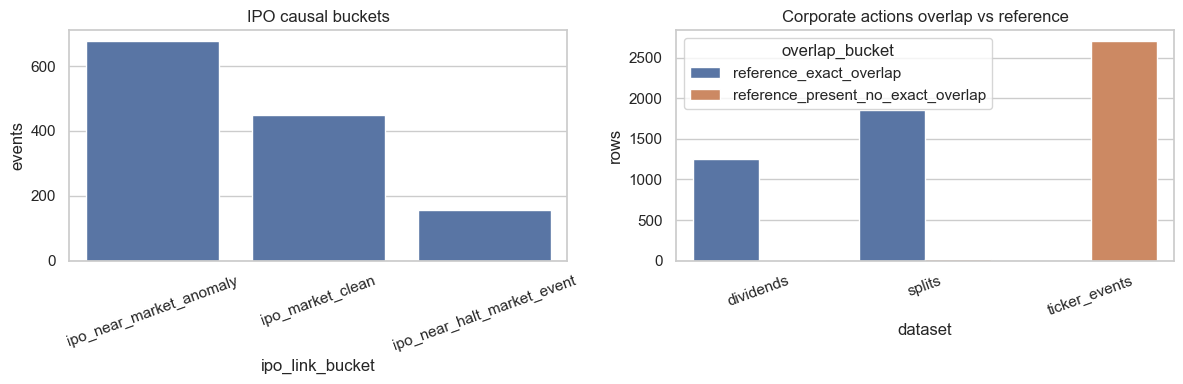

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.barplot(data=additional_ipo_link_summary, x='ipo_link_bucket', y='events', ax=axes[0])
axes[0].set_title('IPO causal buckets')
axes[0].tick_params(axis='x', rotation=20)
sns.barplot(data=additional_corp_actions_reference_overlap_summary, x='dataset', y='rows', hue='overlap_bucket', ax=axes[1])
axes[1].set_title('Corporate actions overlap vs reference')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 10. Lectura Actual

- `financials_core` sale estructuralmente fuerte.
- `news` sale como subbloque rico y causalmente útil, pero con ambigüedad multi-ticker enorme que obliga a separar mono-ticker de multi-ticker.
- `ipos` sí aporta contexto causal real para fragilidad temprana de mercado.
- `dividends` y `splits` de `additional` son casi redundantes con `reference`.
- `ticker_events` de `additional` no solapan de forma exacta con `reference` y quedan en revisión.
- `financials_ratios` queda en revisión por cobertura efectiva baja.
- `corporate_actions_additional` queda útil sobre todo como capa secundaria o de contraste.
- `economic` sale limpio como capa macro larga.

## 11. Viewer Causal
Usa este viewer para revisar manualmente casos de `news` e `ipos` con overlay de `daily + quotes + trades + halts`. Los buckets grandes deben revisarse con filtro de `search` y `top N`.


In [14]:
get_ipython().run_line_magic('run', "C:/TSIS_Data/02_backtest_SmallCaps/notebooks/00_data_certification/auditoria/additional/cell_code/01_additional_causal_overlay.py")


In [15]:
build_additional_viewer()
